In [1]:
import json 
import os
from compare_PINs import *
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import csv
from weekly_retrieval import *
from pathlib import Path

%matplotlib inline  
number_windows = 30
model = "gpt-4o"

In [2]:
# Pakistan 
start_dt = pd.to_datetime('2025-11-16')

months_add, weeks_add, days_add = 0,0,3

end_dt = start_dt + pd.DateOffset(
    months=months_add,
    weeks=weeks_add,
    days=days_add
)

pakistan = {
    "disaster": "violence, attack",
    "country":  "Pakistan",
    "iso2": "PK",
    "iso3": "PAK",
    "month": "January",
    "year": 2026,
    "location": "Pakistan",
    "start_dt": start_dt.strftime("%Y-%m-%d"),
    "end_dt": end_dt.strftime("%Y-%m-%d"),
    "number_windows": number_windows
}


# Sudan
start_dt = pd.to_datetime('2024-10-04')
months_add, weeks_add, days_add = 0,0,3

end_dt = start_dt + pd.DateOffset(
    months=months_add,
    weeks=weeks_add,
    days=days_add
)

sudan = {
    "disaster": "civil war, violence, attack",
    "country":  "Sudan",
    "iso2": "SD",
    "iso3": "SDN",
    "month": "April",
    "year": 2024,
    "location": "Sudan",
    "start_dt": start_dt.strftime("%Y-%m-%d"),
    "end_dt": end_dt.strftime("%Y-%m-%d"),
    "number_windows": number_windows
}

# Syria
start_dt = pd.to_datetime('2024-12-08')
months_add, weeks_add, days_add = 0,0,3

end_dt = start_dt + pd.DateOffset(
    months=months_add,
    weeks=weeks_add,
    days=days_add
)

syria = {
    "disaster": "civil war, violence, attack, war",
    "country":  "Syria",
    "iso2": "SY",
    "iso3": "SYR",
    "month": "December",
    "year": 2024,
    "location": "Syria",
    "start_dt": start_dt.strftime("%Y-%m-%d"),
    "end_dt": end_dt.strftime("%Y-%m-%d"),
    "number_windows": number_windows
}

# Iran
start_dt = pd.to_datetime('2026-03-19')
months_add, weeks_add, days_add = 0,0,3

end_dt = start_dt + pd.DateOffset(
    months=months_add,
    weeks=weeks_add,
    days=days_add
)

iran = {
    "disaster": "war, violence, attack",
    "country":  "Iran",
    "iso2": "IR",
    "iso3": "IRN",
    "month": "March",
    "year": 2026,
    "location": "Iran",
    "start_dt": start_dt.strftime("%Y-%m-%d"),
    "end_dt": end_dt.strftime("%Y-%m-%d"),
    "number_windows": number_windows
}


Week 1/30: 2025-12-19 -> 2025-12-22
Num filtered docs after factcheck =  0
🟡  Week 1/30: No news retrieved for war, violence, attack
✅  window 1/30 processed – nNews = 0

Week 2/30: 2025-12-22 -> 2025-12-25
Num filtered docs after factcheck =  0
🟡  Week 2/30: No news retrieved for war, violence, attack
✅  window 2/30 processed – nNews = 0

Week 3/30: 2025-12-25 -> 2025-12-28
Num filtered docs after factcheck =  1
all of the info: {'People affected': None, 'People displaced': None, 'People in need': None, 'People assisted': None, 'Fatalities': None, 'Economic losses': None, 'Locations': ['null']}
   📥  info stored for week 2025-12-25
✅  window 3/30 processed – nNews = 1

Week 4/30: 2025-12-28 -> 2025-12-31
Num filtered docs after factcheck =  0
🟡  Week 4/30: No news retrieved for war, violence, attack
✅  window 4/30 processed – nNews = 0

Week 5/30: 2025-12-31 -> 2026-01-03
Num filtered docs after factcheck =  1
all of the info: {'People affected': None, 'People displaced': None, 'Peop

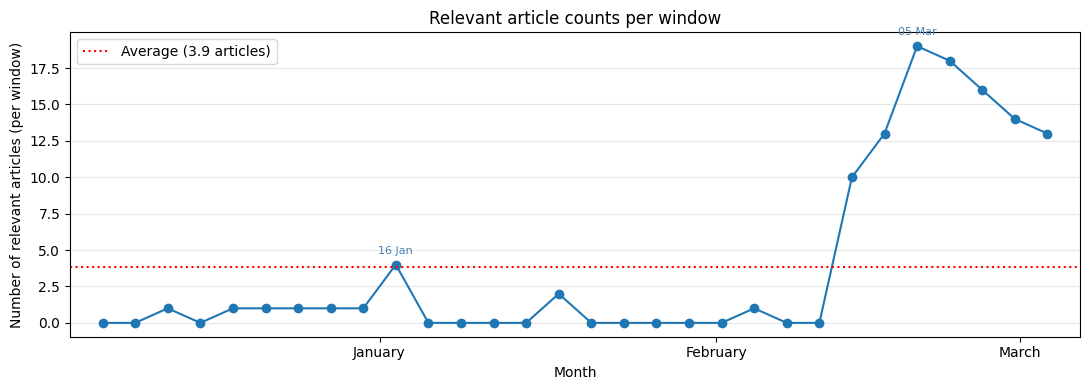

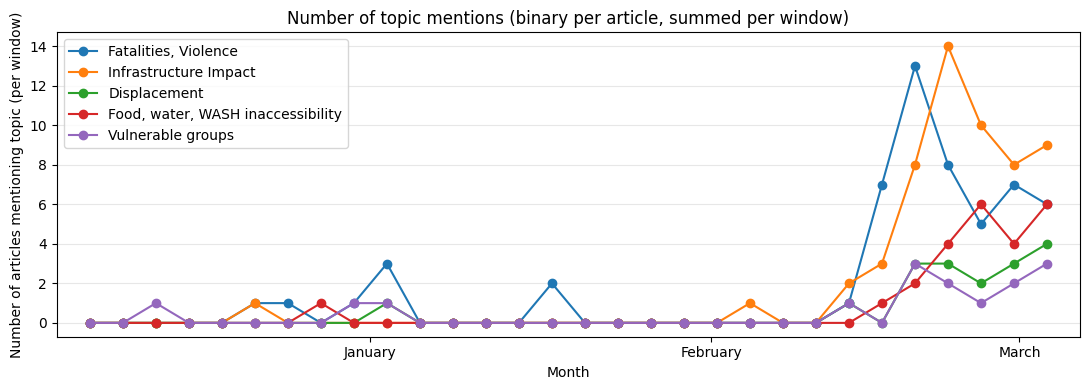

In [3]:
event_details = iran


path_info, results = run_past_week_windows(event_details)
nr_docs, avg = plot_weekly_results(results)

In [4]:
print(nr_docs)
avg

0      0
1      0
2      1
3      0
4      1
5      1
6      1
7      1
8      1
9      4
10     0
11     0
12     0
13     0
14     2
15     0
16     0
17     0
18     0
19     0
20     1
21     0
22     0
23    10
24    13
25    19
26    18
27    16
28    14
29    13
Name: num_relevant_docs, dtype: int64


3.8666666666666667

Parameters        : N=4 windows lookback, threshold=50% increase
Total 72h windows : 30
Flagged windows   : 9
Escalation periods: 5
Avg duration      : 5.4 days (1.8 × 72h windows)
Avg gap between escalations: 10.5 days

  Period 1: 2025-12-31 → 2026-01-06  (2 windows, 6 days, peak 1 docs, avg +200%)
  Period 2: 2026-01-15 → 2026-01-18  (1 windows, 3 days, peak 4 docs, avg +300%)
  Period 3: 2026-01-30 → 2026-02-02  (1 windows, 3 days, peak 2 docs, avg +200000000%)
  Period 4: 2026-02-17 → 2026-02-20  (1 windows, 3 days, peak 1 docs, avg +100000000%)
  Period 5: 2026-02-26 → 2026-03-10  (4 windows, 12 days, peak 19 docs, avg +1144%)


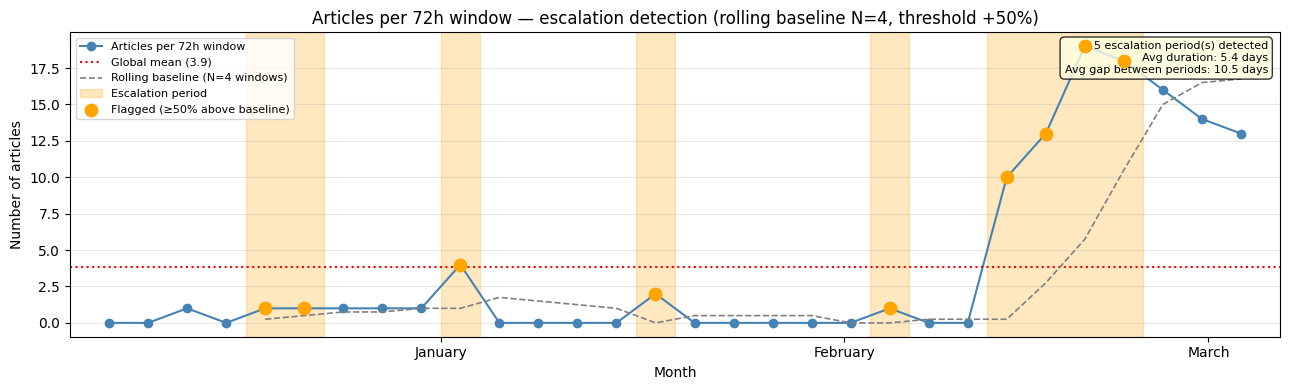

In [5]:
def detect_escalation_periods(results, N=4, threshold=0.5):
    """
    Detects rapid escalation periods in article counts using a rolling
    baseline average and a percentage-increase threshold.

    Parameters
    ----------
    results      : dict from run_past_week_windows(), needs "period_start",
                   "period_end", "weekly" with "num_relevant_docs"
    N            : int   — number of past 72h windows used to compute baseline
                   (default 4, i.e. ~12 days lookback)
    threshold    : float — minimum fractional increase above baseline to flag
                   (default 0.5, i.e. 50% above rolling average)

    Returns
    -------
    dict with flagged_windows, escalation_periods, avg_duration_days,
    avg_duration_windows, avg_windows_between_escalations, parameters used
    """
    import numpy as np

    period_start = pd.to_datetime(results["period_start"])
    weekly       = results["weekly"]
    n            = len(weekly)
    epsilon      = 1e-6

    # --- reconstruct window midpoints and edges ---
    win_starts = [period_start + pd.Timedelta(days=3 * k) for k in range(n)]
    win_ends   = [ws + pd.Timedelta(days=3) for ws in win_starts]
    win_mids   = [ws + pd.Timedelta(hours=36) for ws in win_starts]
    counts     = np.array([w.get("num_relevant_docs", 0) for w in weekly], dtype=float)

    # --- global average (for reference line on plot) ---
    global_avg = counts.mean()

    # --- rolling baseline + flagging ---
    flagged_windows = []
    pct_increases   = []

    for i in range(N, n):                             # first N windows have no full baseline
        baseline   = counts[i - N:i].mean()
        pct_inc    = (counts[i] - baseline) / (baseline + epsilon)
        pct_increases.append(pct_inc)

        if pct_inc >= threshold:
            flagged_windows.append({
                "window_index" : i,
                "window_start" : win_starts[i].strftime("%Y-%m-%d"),
                "window_end"   : win_ends[i].strftime("%Y-%m-%d"),
                "num_docs"     : int(counts[i]),
                "baseline_avg" : round(float(baseline), 2),
                "pct_increase" : round(float(pct_inc), 3),
            })

    # --- group consecutive flagged windows into escalation periods ---
    escalation_periods = []
    if flagged_windows:
        flagged_indices = [fw["window_index"] for fw in flagged_windows]
        group = [flagged_indices[0]]
        for idx in flagged_indices[1:]:
            if idx == group[-1] + 1:
                group.append(idx)
            else:
                escalation_periods.append(group)
                group = [idx]
        escalation_periods.append(group)

        escalation_periods = [
            {
                "period_start"  : win_starts[g[0]].strftime("%Y-%m-%d"),
                "period_end"    : win_ends[g[-1]].strftime("%Y-%m-%d"),
                "n_windows"     : len(g),
                "duration_days" : 3 * len(g),
                "peak_docs"     : int(max(counts[i] for i in g)),
                "avg_pct_inc"   : round(float(np.mean([
                                    fw["pct_increase"] for fw in flagged_windows
                                    if fw["window_index"] in g
                                  ])), 3),
            }
            for g in escalation_periods
        ]

    # --- average duration + frequency ---
    avg_duration_days    = np.mean([p["duration_days"] for p in escalation_periods]) if escalation_periods else 0.0
    avg_duration_windows = np.mean([p["n_windows"]     for p in escalation_periods]) if escalation_periods else 0.0

    # gaps between escalation periods (in windows)
    if len(escalation_periods) > 1:
        gap_starts = [pd.to_datetime(escalation_periods[i+1]["period_start"]) for i in range(len(escalation_periods)-1)]
        gap_ends   = [pd.to_datetime(escalation_periods[i]["period_end"])     for i in range(len(escalation_periods)-1)]
        gaps_days  = [(gs - ge).days for gs, ge in zip(gap_starts, gap_ends)]
        avg_gap_days = np.mean(gaps_days)
    else:
        avg_gap_days = None

    # --- print summary ---
    print(f"Parameters        : N={N} windows lookback, threshold={threshold*100:.0f}% increase")
    print(f"Total 72h windows : {n}")
    print(f"Flagged windows   : {len(flagged_windows)}")
    print(f"Escalation periods: {len(escalation_periods)}")
    print(f"Avg duration      : {avg_duration_days:.1f} days ({avg_duration_windows:.1f} × 72h windows)")
    if avg_gap_days is not None:
        print(f"Avg gap between escalations: {avg_gap_days:.1f} days")
    print()
    for i, p in enumerate(escalation_periods, 1):
        print(f"  Period {i}: {p['period_start']} → {p['period_end']}  "
              f"({p['n_windows']} windows, {p['duration_days']} days, "
              f"peak {p['peak_docs']} docs, avg +{p['avg_pct_inc']*100:.0f}%)")

    # --- plot ---
    fig, ax = plt.subplots(figsize=(13, 4))

    # main line
    ax.plot(win_mids, counts, marker="o", color="steelblue",
            linewidth=1.5, label="Articles per 72h window")

    # global average
    ax.axhline(global_avg, color="red", linestyle=":",
               linewidth=1.5, label=f"Global mean ({global_avg:.1f})")

    # rolling baseline as a line
    baseline_values = [np.nan] * N
    for i in range(N, n):
        baseline_values.append(counts[i - N:i].mean())
    ax.plot(win_mids, baseline_values, color="grey", linestyle="--",
            linewidth=1.2, label=f"Rolling baseline (N={N} windows)")

    # shade escalation periods
    for i, p in enumerate(escalation_periods):
        ps = pd.to_datetime(p["period_start"])
        pe = pd.to_datetime(p["period_end"])
        ax.axvspan(ps, pe, color="orange", alpha=0.25,
                   label="Escalation period" if i == 0 else None)

    # highlight flagged dots
    flagged_idx = [fw["window_index"] for fw in flagged_windows]
    ax.scatter(
        [win_mids[i] for i in flagged_idx],
        [counts[i]   for i in flagged_idx],
        color="orange", zorder=5, s=80,
        label=f"Flagged (≥{threshold*100:.0f}% above baseline)"
    )

    # annotate flagged dots with % increase
    for fw in flagged_windows:
        i = fw["window_index"]
        ax.annotate(
            f"",
            xy=(win_mids[i], counts[i]),
            xytext=(0, 10), textcoords="offset points",
            ha="center", fontsize=7.5, color="darkorange"
        )

    # frequency annotation box
    freq_text = (f"{len(escalation_periods)} escalation period(s) detected\n"
                 f"Avg duration: {avg_duration_days:.1f} days\n" +
                 (f"Avg gap between periods: {avg_gap_days:.1f} days" if avg_gap_days else ""))
    ax.text(0.99, 0.97, freq_text, transform=ax.transAxes,
            fontsize=8, verticalalignment="top", horizontalalignment="right",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow", alpha=0.8))

    # x-axis: month names
    plot_start = min(win_mids) - pd.Timedelta(days=3)
    plot_end   = max(win_mids) + pd.Timedelta(days=3)
    month_starts_range = pd.date_range(
        plot_start.normalize().replace(day=1),
        plot_end.normalize().replace(day=1),
        freq="MS"
    )
    month_mids_ticks = month_starts_range + pd.Timedelta(days=14)
    ax.set_xticks(month_mids_ticks)
    ax.set_xticklabels([d.strftime("%B") for d in month_mids_ticks], rotation=0)
    ax.set_xlim(plot_start, plot_end)
    ax.grid(True, axis="y", alpha=0.3)

    ax.set_xlabel("Month")
    ax.set_ylabel("Number of articles")
    ax.set_title(
        f"Articles per 72h window — escalation detection "
        f"(rolling baseline N={N}, threshold +{threshold*100:.0f}%)"
    )
    ax.legend(loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

    return {
        "flagged_windows"           : flagged_windows,
        "escalation_periods"        : escalation_periods,
        "avg_duration_days"         : round(avg_duration_days, 1),
        "avg_duration_windows"      : round(avg_duration_windows, 1),
        "avg_gap_between_days"      : round(avg_gap_days, 1) if avg_gap_days else None,
        "global_mean_docs"          : round(global_avg, 2),
        "N_lookback"                : N,
        "threshold"                 : threshold,
    }

escalation = detect_escalation_periods(results)